# Tema : Modelo Prophet

![](src/img/logo_utb.png)
![](src/img/logo_etd.png)
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

# Ejercicio 1. Demanda de electricidad cada media hora

- Una aplicación común de estos modelos es la modelización de la demanda de electricidad. Tenemos una muestra la demanda de electricidad cada media hora (MWh) en Victoria, Australia, durante el período 2012-2014, junto con las temperaturas (en grados Celsius) para el mismo período en Melbourne (la ciudad más grande de Victoria).


In [5]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos Prophet
from prophet import Prophet
from prophet.diagnostics import performance_metrics
from prophet.diagnostics import cross_validation
from prophet.plot import plot_cross_validation_metric

import warnings
warnings.filterwarnings('ignore')


In [6]:
# datos de electricidad
github_data = "https://raw.githubusercontent.com/fersalme/regresion-lineal-series-tiempo/refs/heads/main/data/vic_elec.csv"
vic_elec = pd.read_csv(github_data, parse_dates=["ds"])

vic_elec_df = (
    vic_elec
    .pivot(index=["ds", "Holiday"], columns="unique_id", values="y")
    .reset_index().rename_axis(None, axis="columns")
    .assign(ds=lambda x: pd.to_datetime(x["ds"]).dt.normalize())
    .groupby(["ds", "Holiday"])
    .agg({
        "Demand": "sum",
        "Temperature": "max"
    })
    .reset_index()
    .assign(
        Demand=lambda x: x["Demand"] / 1e3,
        weekend=lambda x: x["ds"].dt.dayofweek.isin([5, 6]),
        Working_Day=lambda x: ~x["Holiday"] & ~x["weekend"],
        Cooling=lambda x: x["Temperature"].clip(lower=18)
    )
    .drop(columns=["weekend", "Holiday"])
)

vic_elec_df.head()


,ds,Demand,Temperature,Working_Day,Cooling
0,2012-01-01,222.437912,32.7,False,32.7
1,2012-01-02,257.964724,39.6,False,39.6
2,2012-01-03,267.098605,31.8,True,31.8
3,2012-01-04,222.742287,25.1,True,25.1
4,2012-01-05,210.585240,21.2,True,21.2


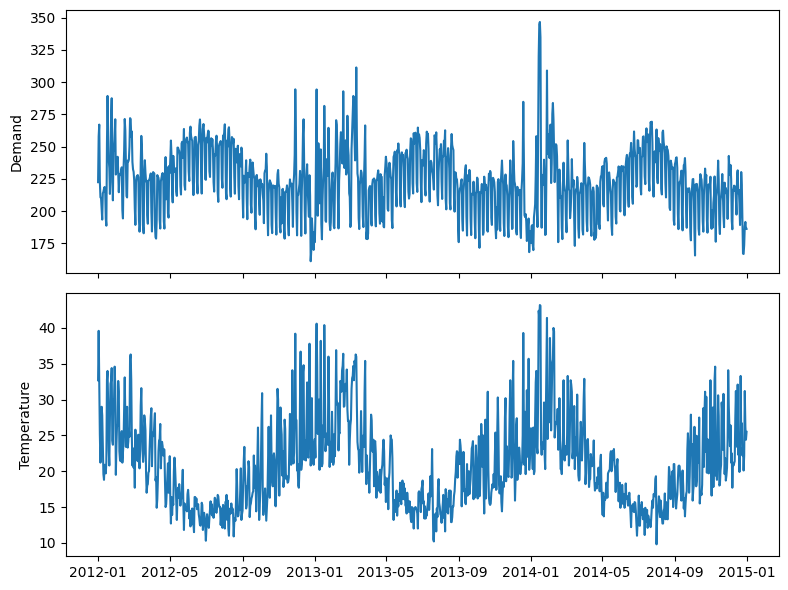

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(vic_elec_df["ds"], vic_elec_df["Demand"])
axes[0].set_ylabel("Demand")
axes[1].plot(vic_elec_df["ds"], vic_elec_df["Temperature"])
axes[1].set_ylabel("Temperature")
plt.tight_layout()
plt.show()

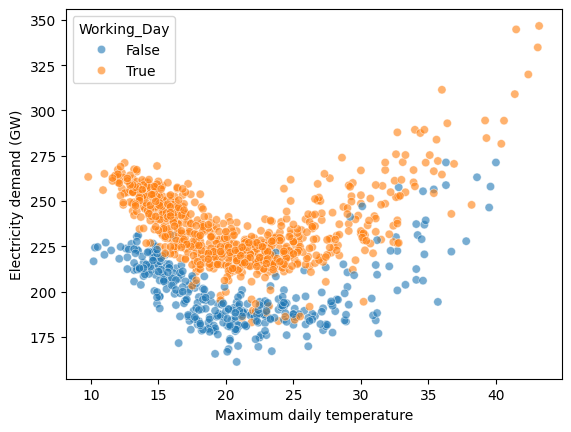

In [8]:
fig, ax = plt.subplots()
sns.scatterplot(data=vic_elec_df, x="Temperature", y="Demand",
    hue="Working_Day", palette="tab10", alpha=0.6, ax=ax)
ax.set(
    xlabel="Maximum daily temperature",
    ylabel="Electricity demand (GW)",
)
plt.show()

Si se representa la demanda de electricidad en función de la temperatura, se observa que existe una relación no lineal entre ambas, con un aumento de la demanda para temperaturas bajas (debido a la calefacción) y un aumento para temperaturas altas (debido a la refrigeración).

10:13:56 - cmdstanpy - INFO - Chain [1] start processing
10:13:56 - cmdstanpy - INFO - Chain [1] done processing


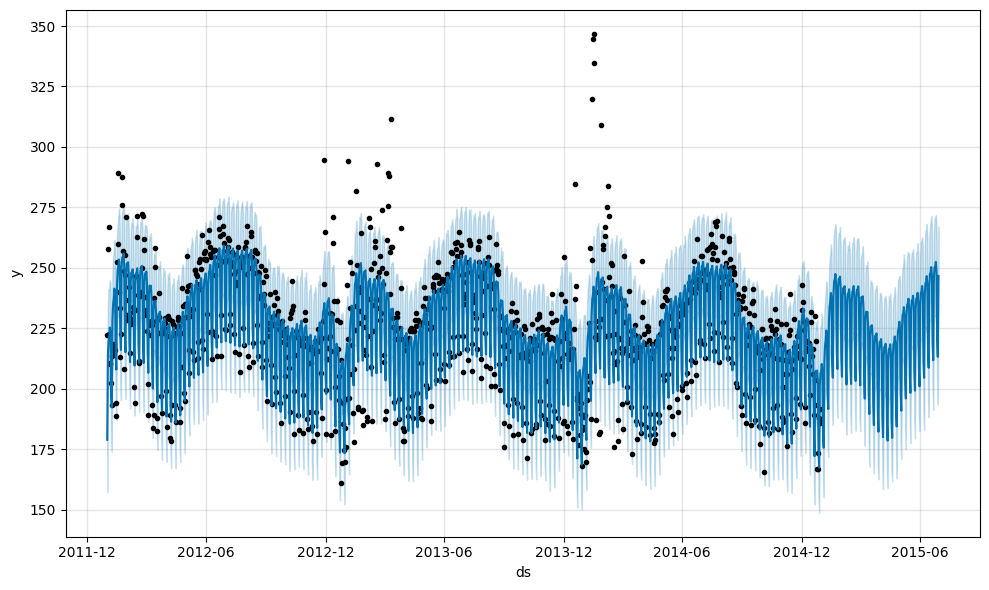

In [9]:
# Test entrenamiento y prueba
# Estimar solo demanda : Dataframe must have columns "ds" and "y" with the dates and values respectively.
demanda = vic_elec_df[["ds", "Demand"]].copy()
demanda.rename(columns={"Demand" : "y"}, inplace=True)

# Definir y ajustar el modelo
model = Prophet()
model.fit(demanda)

# Predecir 180 dias de demanda (6 meses)
future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)
fig1 = model.plot(forecast)

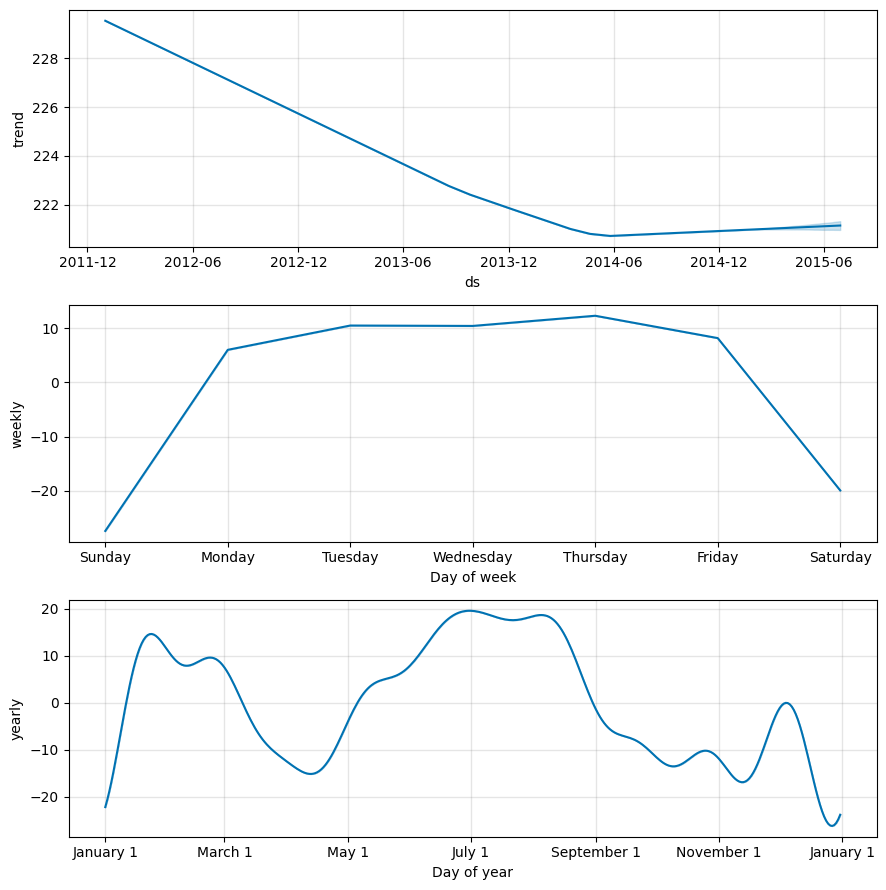

In [10]:
fig2 = model.plot_components(forecast)

In [11]:
df_cv = cross_validation(
    model=model,
    initial='730 days',   # Tamaño del conjunto inicial de entrenamiento
    period='180 days',    # Frecuencia de los cortes de validación
    horizon='365 days',   # Horizonte de pronóstico a evaluar
    parallel='processes'  # Paralelización: 'processes' | 'threads' | None
)
df_p = performance_metrics(df_cv)
df_p

Importing plotly failed. Interactive plots will not work.
10:13:58 - cmdstanpy - INFO - Chain [1] start processing
10:13:58 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days,1913.664957,43.745456,29.289623,0.110595,0.083033,0.119668,0.527778
1,37 days,1928.573054,43.915522,29.485159,0.109310,0.083033,0.119219,0.527778
2,38 days,1993.854182,44.652594,30.320077,0.111056,0.083033,0.121737,0.527778
3,39 days,2115.737680,45.997149,31.681859,0.115175,0.083033,0.127045,0.527778
4,40 days,2187.403179,46.769682,32.872319,0.119598,0.086728,0.132180,0.500000
...,...,...,...,...,...,...,...,...
325,361 days,261.339707,16.166005,11.881524,0.058001,0.035316,0.059152,0.750000
326,362 days,274.859244,16.578879,12.218758,0.059878,0.035316,0.061243,0.722222
327,363 days,271.406237,16.474412,12.007129,0.058736,0.024474,0.060036,0.722222
328,364 days,272.633886,16.511629,12.056430,0.059280,0.024474,0.060472,0.722222


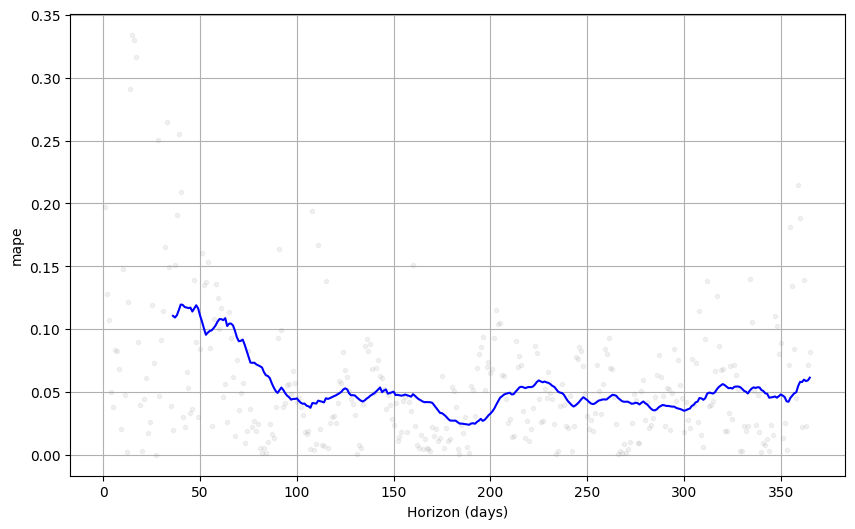

In [12]:
fig = plot_cross_validation_metric(df_cv, metric='mape')

10:13:59 - cmdstanpy - INFO - Chain [1] start processing
10:13:59 - cmdstanpy - INFO - Chain [1] done processing


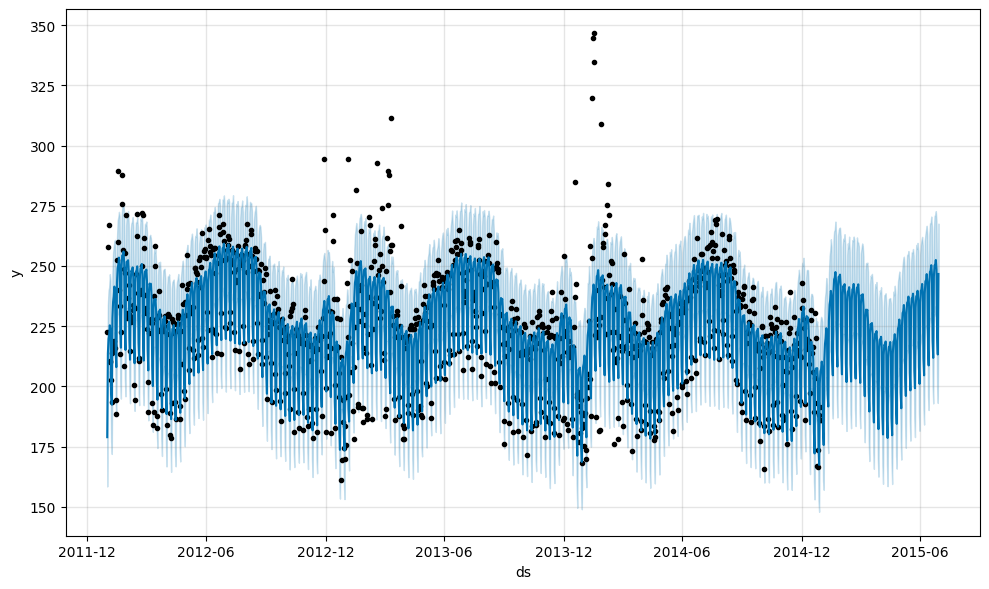

In [13]:
# Modelo prophet 2 incluyendo regresoras
demanda_exog = vic_elec_df.copy()
demanda_exog.rename(columns={"Demand" : "y"}, inplace=True)

#  Construir el modelo
modelo_exog = Prophet()
modelo_exog.add_regressor("Temperature")
modelo_exog.add_regressor("Working_Day")

# Estimar el modelo
modelo_exog.fit(demanda_exog)

# Predecir 180 dias de demanda (6 meses)
future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)
fig1 = model.plot(forecast)

In [14]:
df_cv = cross_validation(
    model=modelo_exog,
    initial='730 days',   # Tamaño del conjunto inicial de entrenamiento
    period='180 days',    # Frecuencia de los cortes de validación
    horizon='365 days',   # Horizonte de pronóstico a evaluar
    parallel='processes'  # Paralelización: 'processes' | 'threads' | None
)
df_p = performance_metrics(df_cv)
df_p

Importing plotly failed. Interactive plots will not work.
10:14:00 - cmdstanpy - INFO - Chain [1] start processing
10:14:01 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days,1067.213946,32.668241,22.119726,0.083333,0.069438,0.088477,0.555556
1,37 days,1086.300894,32.959079,22.731976,0.085293,0.071309,0.090583,0.527778
2,38 days,1112.585248,33.355438,23.171589,0.085751,0.071309,0.091483,0.527778
3,39 days,1166.444350,34.153248,24.006497,0.088062,0.071309,0.094366,0.527778
4,40 days,1192.694011,34.535402,24.831727,0.091361,0.075638,0.097897,0.500000
...,...,...,...,...,...,...,...,...
325,361 days,69.073350,8.311038,6.380961,0.030356,0.025771,0.030979,0.944444
326,362 days,71.970340,8.483533,6.626080,0.031669,0.027441,0.032335,0.944444
327,363 days,76.717487,8.758852,6.852043,0.032828,0.027441,0.033400,0.944444
328,364 days,81.560526,9.031087,7.010424,0.033979,0.027441,0.034381,0.916667


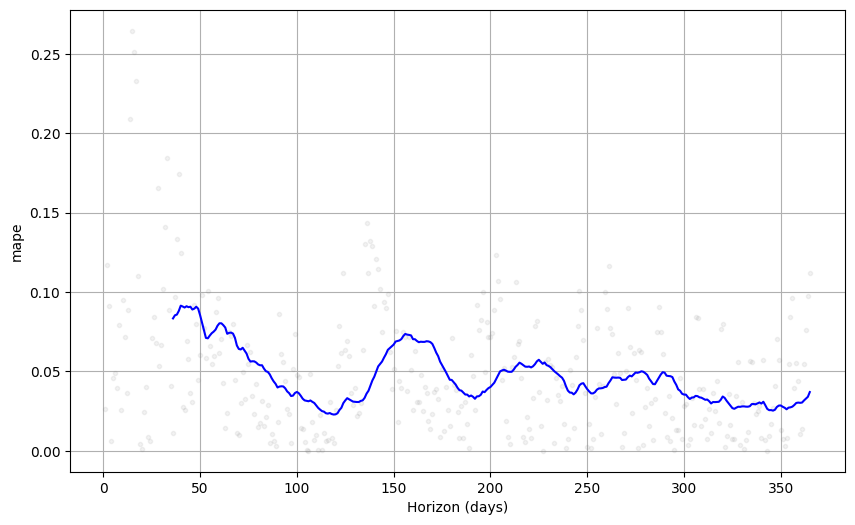

In [15]:
fig = plot_cross_validation_metric(df_cv, metric='mape')